In [39]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Configuração dos caminhos do projeto

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

PROCESSED_FILE = PROCESSED_DIR / "wine_quality_clean.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [41]:
# Carregamento da base limpa

wine_df = pd.read_csv(PROCESSED_FILE)

print(f"Dimensões da base limpa: {wine_df.shape[0]} linhas e {wine_df.shape[1]} colunas")

wine_df.head()

Dimensões da base limpa: 1018 linhas e 13 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [42]:
# Conferindo as colunas disponíveis

wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary'],
      dtype='object')

In [43]:
# Calculando a correlação entre todas as colunas

matriz_correlacao = wine_df.corr(numeric_only=True)

matriz_correlacao

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
fixed acidity,1.000000,-0.236894,0.668178,0.173726,0.102446,-0.152582,-0.100716,0.683120,-0.692597,0.181277,-0.077624,0.115826,0.107952
volatile acidity,-0.236894,1.000000,-0.542459,-0.008701,0.051371,-0.007556,0.071870,0.028614,0.226348,-0.280601,-0.207419,-0.409340,-0.302343
citric acid,0.668178,-0.542459,1.000000,0.178362,0.246843,-0.048523,0.047903,0.368832,-0.553370,0.347933,0.102134,0.241565,0.237369
residual sugar,0.173726,-0.008701,0.178362,1.000000,0.058410,0.146929,0.188528,0.363112,-0.120993,0.006738,0.070779,0.022718,0.064405
chlorides,0.102446,0.051371,0.246843,0.058410,1.000000,0.014612,0.044947,0.210932,-0.277536,0.392989,-0.234283,-0.122214,-0.105595
free sulfur dioxide,-0.152582,-0.007556,-0.048523,0.146929,0.014612,1.000000,0.661089,-0.049664,0.051018,0.031844,-0.060876,-0.071083,-0.067319
total sulfur dioxide,-0.100716,0.071870,0.047903,0.188528,0.044947,0.661089,1.000000,0.053496,-0.071037,0.004963,-0.197917,-0.182214,-0.114990
density,0.683120,0.028614,0.368832,0.363112,0.210932,-0.049664,0.053496,1.000000,-0.366173,0.138789,-0.504748,-0.185187,-0.166497
pH,-0.692597,0.226348,-0.553370,-0.120993,-0.277536,0.051018,-0.071037,-0.366173,1.000000,-0.192979,0.230655,-0.057592,-0.065270
sulphates,0.181277,-0.280601,0.347933,0.006738,0.392989,0.031844,0.004963,0.138789,-0.192979,1.000000,0.096239,0.257519,0.213071


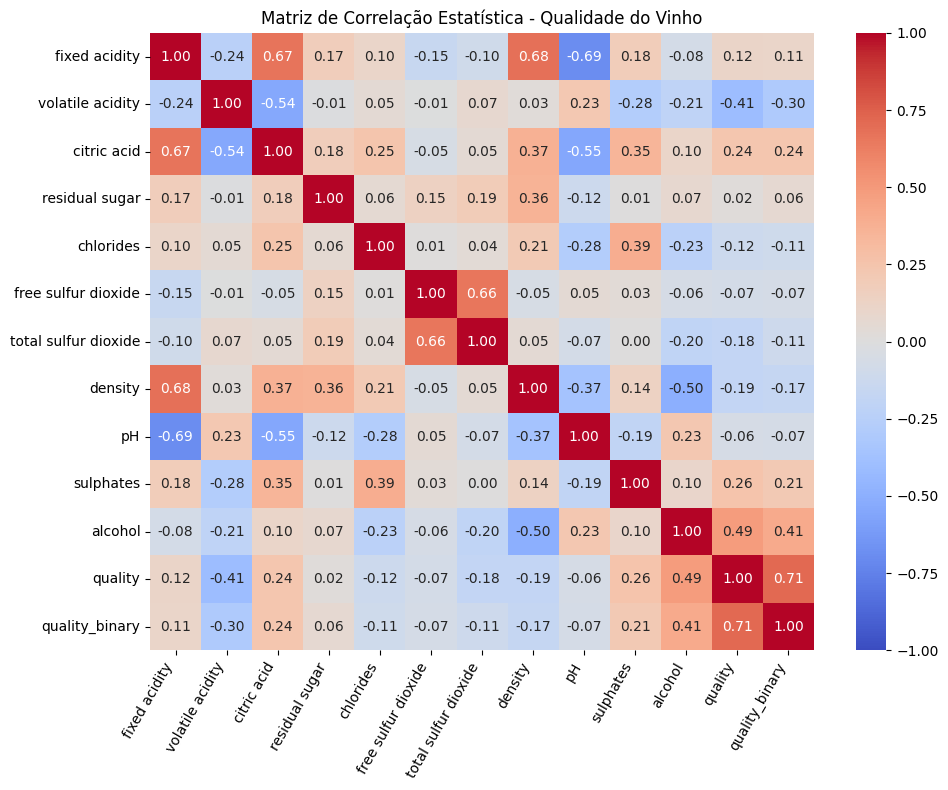

Gráfico salvo em: /Users/assis/Documents/Jacque/FIAP/FASE02/projeto/Tech-Challenge-FIAP-Fase-2---Wine-Quality/results/figures/matriz_correlacao.png


In [44]:
# Configurando o tamanho e exibindo o mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Estatística - Qualidade do Vinho')

plt.xticks(rotation=60, ha='right') # Inclina a legenda inferior em 75 graus e alinha à direita
plt.yticks(rotation=0)             # Deixa a legenda da lateral perfeitamente deitada (horizontal)

# Salvando o gráfico na pasta 'results'
plt.tight_layout()
plt.savefig(FIGURES_DIR / "matriz_correlacao.png", bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {FIGURES_DIR / 'matriz_correlacao.png'}")

In [45]:
# Isolando a coluna de qualidade e ordenando as correlações do maior para o menor
influenciadores = matriz_correlacao['quality_binary'].sort_values(ascending=False)

print("Influência de cada componente químico na Alta Qualidade (Nota >= 7):")
print("-" * 65)
print(influenciadores)

Influência de cada componente químico na Alta Qualidade (Nota >= 7):
-----------------------------------------------------------------
quality_binary          1.000000
quality                 0.713515
alcohol                 0.410331
citric acid             0.237369
sulphates               0.213071
fixed acidity           0.107952
residual sugar          0.064405
pH                     -0.065270
free sulfur dioxide    -0.067319
chlorides              -0.105595
total sulfur dioxide   -0.114990
density                -0.166497
volatile acidity       -0.302343
Name: quality_binary, dtype: float64


In [46]:
# Salvando a tabela de correlações 

influenciadores.to_csv(
    TABLES_DIR / "correlacoes_influenciadores.csv",
    header=["correlacao"]
)

print(f"Tabela salva em: {TABLES_DIR / 'correlacoes_influenciadores.csv'}")

Tabela salva em: /Users/assis/Documents/Jacque/FIAP/FASE02/projeto/Tech-Challenge-FIAP-Fase-2---Wine-Quality/results/tables/correlacoes_influenciadores.csv


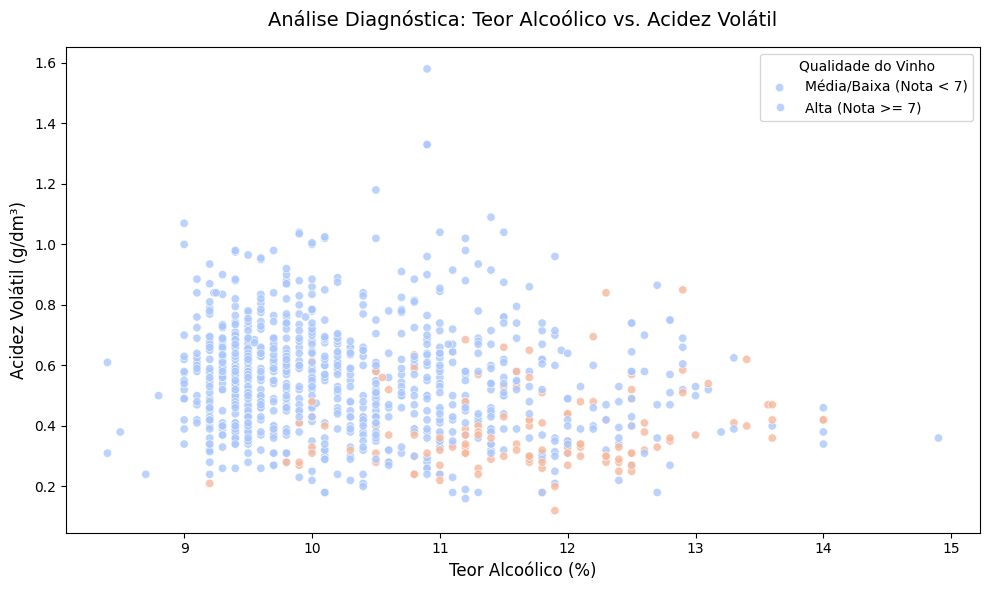

Gráfico salvo em: /Users/assis/Documents/Jacque/FIAP/FASE02/projeto/Tech-Challenge-FIAP-Fase-2---Wine-Quality/results/figures/dispersao_alcohol_vs_acidez.png


In [47]:
# Criando o gráfico de Dispersão Diagnóstico

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Criando o gráfico de dispersão cruzando os dois principais influenciadores
# Usamos os dados brutos (wine_df) para as legendas ficarem com os valores reais de negócio
sns.scatterplot(
    x='alcohol', 
    y='volatile acidity', 
    hue='quality_binary', 
    data=wine_df, 
    palette='coolwarm', 
    alpha=0.8
)

# Customizando os títulos e legendas para uma linguagem executiva
plt.title('Análise Diagnóstica: Teor Alcoólico vs. Acidez Volátil', fontsize=14, pad=15)
plt.xlabel('Teor Alcoólico (%)', fontsize=12)
plt.ylabel('Acidez Volátil (g/dm³)', fontsize=12)

# Ajustando a legenda lateral do gráfico
plt.legend(title='Qualidade do Vinho', labels=['Média/Baixa (Nota < 7)', 'Alta (Nota >= 7)'])

# Salvando o gráfico na pasta 'results'
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dispersao_alcohol_vs_acidez.png", bbox_inches="tight")
plt.show()

print(f"Gráfico salvo em: {FIGURES_DIR / 'dispersao_alcohol_vs_acidez.png'}")

In [48]:
# Criando uma coluna com rótulos textuais para melhorar a legenda dos gráficos
# 0 = Média/Baixa qualidade
# 1 = Alta qualidade

wine_df["quality_label"] = wine_df["quality_binary"].map({
    0: "Média/Baixa",
    1: "Alta"
})

wine_df["quality_label"].value_counts()

quality_label
Média/Baixa    881
Alta           137
Name: count, dtype: int64

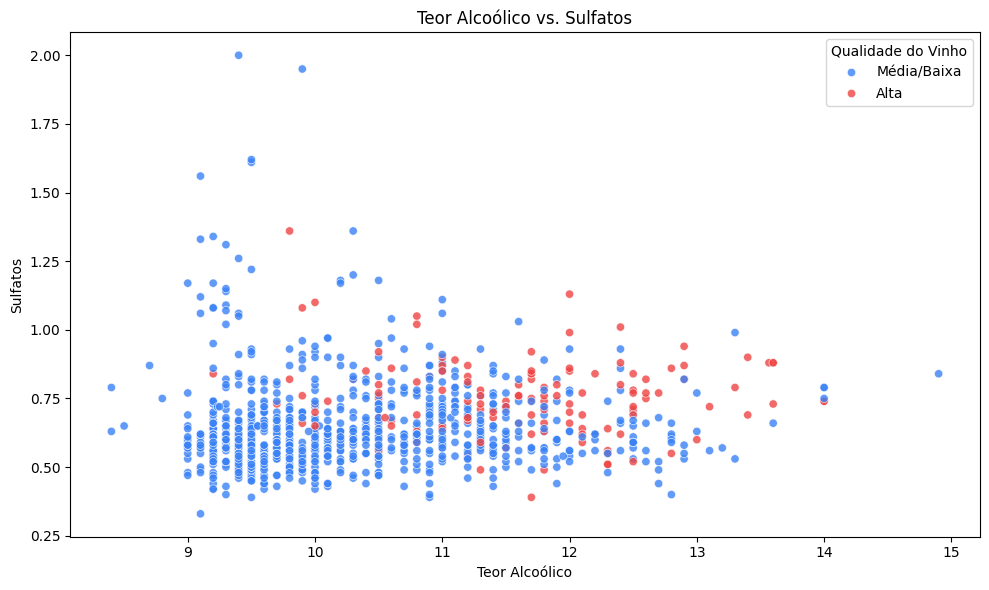

In [49]:
# Exploramos alcohol vs sulphates porque ambas as variáveis apresentaram correlação
# positiva com alta qualidade. Esse gráfico ajuda a verificar se vinhos com maior
# teor alcoólico e maior concentração de sulfatos aparecem mais frequentemente
# na classe de alta qualidade.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="alcohol",
    y="sulphates",
    hue="quality_label",
    data=wine_df,
    palette={
        "Média/Baixa": "#3b82f6",
        "Alta": "#ef4444"
    },
    alpha=0.8
)

plt.title("Teor Alcoólico vs. Sulfatos")
plt.xlabel("Teor Alcoólico")
plt.ylabel("Sulfatos")
plt.legend(title="Qualidade do Vinho")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dispersao_alcohol_vs_sulphates.png", bbox_inches="tight")
plt.show()

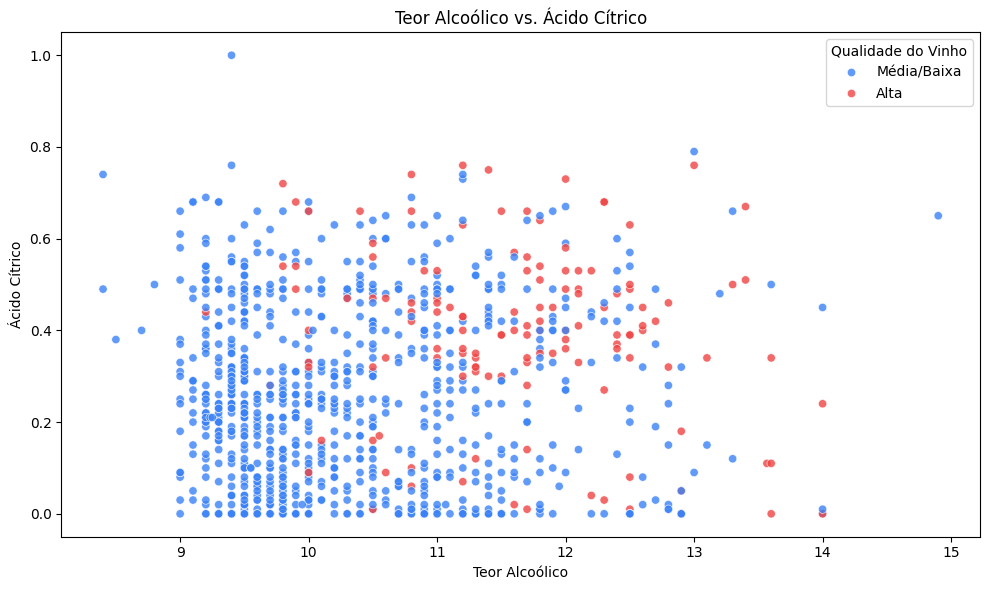

In [50]:
# Exploramos alcohol vs citric acid porque as duas variáveis apresentaram correlação
# positiva com alta qualidade. Esse gráfico ajuda a analisar se vinhos com maior
# teor alcoólico e maior presença de ácido cítrico se concentram mais entre os
# vinhos classificados como alta qualidade.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="alcohol",
    y="citric acid",
    hue="quality_label",
    data=wine_df,
    palette={
        "Média/Baixa": "#3b82f6",
        "Alta": "#ef4444"
    },
    alpha=0.8
)

plt.title("Teor Alcoólico vs. Ácido Cítrico")
plt.xlabel("Teor Alcoólico")
plt.ylabel("Ácido Cítrico")
plt.legend(title="Qualidade do Vinho")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dispersao_alcohol_vs_citric_acid.png", bbox_inches="tight")
plt.show()

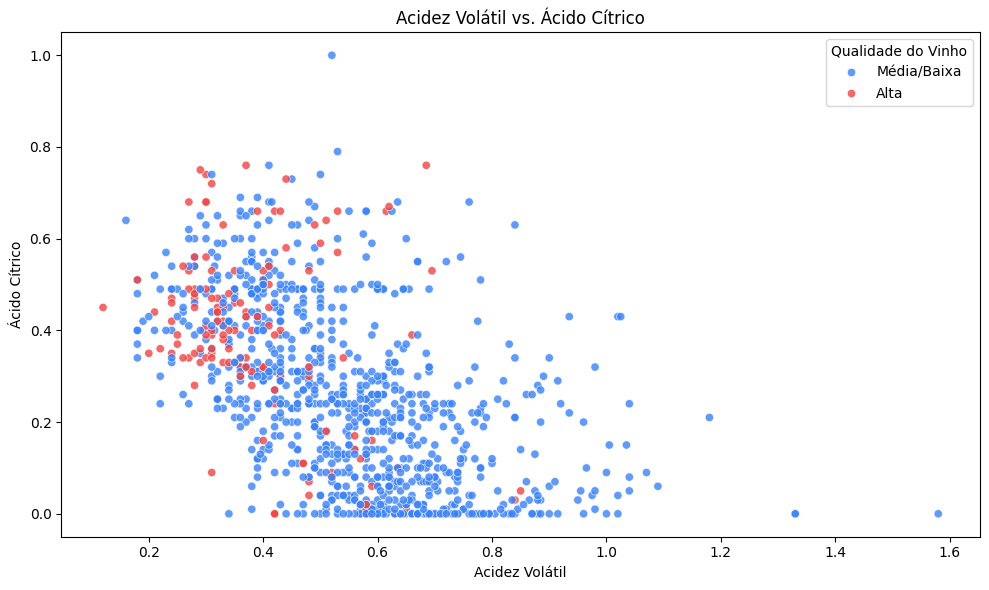

In [51]:
# Exploramos volatile acidity vs citric acid porque elas indicam aspectos diferentes
# da acidez do vinho. A volatile acidity apresentou correlação negativa com alta
# qualidade, enquanto citric acid apresentou correlação positiva. Esse gráfico ajuda
# a observar se vinhos de alta qualidade aparecem em regiões de menor acidez volátil
# e maior ácido cítrico.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="volatile acidity",
    y="citric acid",
    hue="quality_label",
    data=wine_df,
    palette={
        "Média/Baixa": "#3b82f6",
        "Alta": "#ef4444"
    },
    alpha=0.8
)

plt.title("Acidez Volátil vs. Ácido Cítrico")
plt.xlabel("Acidez Volátil")
plt.ylabel("Ácido Cítrico")
plt.legend(title="Qualidade do Vinho")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dispersao_volatile_acidity_vs_citric_acid.png", bbox_inches="tight")
plt.show()

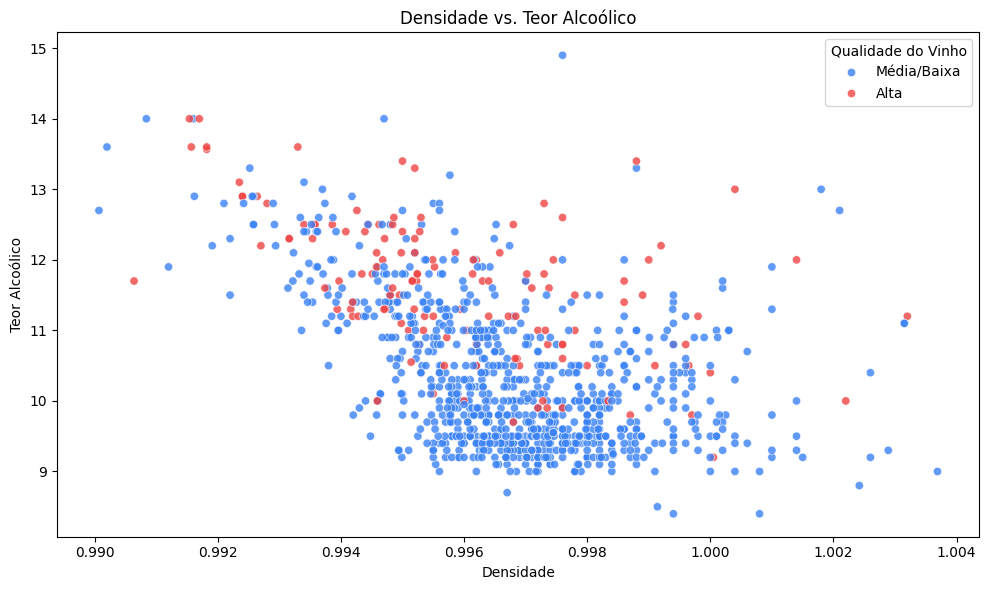

In [52]:
# Exploramos density vs alcohol porque density apresentou correlação negativa com
# alta qualidade, enquanto alcohol apresentou correlação positiva. Além disso,
# essas variáveis podem ter uma relação química importante: vinhos com maior teor
# alcoólico tendem a apresentar menor densidade. Esse gráfico ajuda a verificar se
# essa combinação aparece mais nos vinhos de alta qualidade.

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="density",
    y="alcohol",
    hue="quality_label",
    data=wine_df,
    palette={
        "Média/Baixa": "#3b82f6",
        "Alta": "#ef4444"
    },
    alpha=0.8
)

plt.title("Densidade vs. Teor Alcoólico")
plt.xlabel("Densidade")
plt.ylabel("Teor Alcoólico")
plt.legend(title="Qualidade do Vinho")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dispersao_density_vs_alcohol.png", bbox_inches="tight")
plt.show()